Workflow:

VCF file -- PLINK convert -- LD Pruning -- PCA analysis -- ADMIXTURE Analysis


Using Chr1 took way too long (>1h) so Chr22 was used

In [1]:
!pwd

/Users/amira/Desktop/BIO392/exercises/day10/chr7


In [2]:
!bcftools view -h /Users/amira/Desktop/BIO392/exercises/day10/chr7/ALL.chr7.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz
!bcftools view -H /Users/amira/Desktop/BIO392/exercises/day10/chr7/ALL.chr7.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz | head

##fileformat=VCFv4.3
##FILTER=<ID=PASS,Description="All filters passed">
##fileDate=31052018_15h52m43s
##source=IGSRpipeline
##reference=ftp://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa
##FORMAT=<ID=GT,Number=1,Type=String,Description="Phased Genotype">
##contig=<ID=chr7>
##INFO=<ID=AF,Number=A,Type=Float,Description="Estimated allele frequency in the range (0,1)">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Total number of alternate alleles in called genotypes">
##INFO=<ID=NS,Number=1,Type=Integer,Description="Number of samples with data">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=EAS_AF,Number=A,Type=Float,Description="Allele frequency in the EAS populations calculated from AC and AN, in the range (0,1)">
##INFO=<ID=EUR_AF,Number=A,Type=Float,Description="Allele frequency in the EUR populations calculated from AC and AN, in the range (0,1

In [3]:
%%bash
bcftools view \
  --threads 4 \
  -m2 -M2 \
  -v snps \
  -i 'MAF>0.01' \
  -Oz \
  -o chr7_filtered.vcf.gz \
    /Users/amira/Desktop/BIO392/exercises/day10/chr7/ALL.chr7.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz

Convert VCF → PLINK format

In [60]:
%%bash
plink \
  --vcf /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz \
  --make-bed \
  --out chr7_raw \
  --double-id \
  --vcf-half-call missing \
  --biallelic-only strict

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_raw.log.
Options in effect:
  --biallelic-only strict
  --double-id
  --make-bed
  --out chr7_raw
  --vcf /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz
  --vcf-half-call missing

8192 MB RAM detected; reserving 4096 MB for main workspace.
--vcf: chr7_raw-temporary.bed + chr7_raw-temporary.bim + chr7_raw-temporary.fam
written.
708669 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_raw.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990

In [9]:
!ls -lh /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz

-rw-r--r--@ 1 amira  staff   402M Apr 29 16:44 /Users/amira/Desktop/BIO392/exercises/day10/chr7/chr7_filtered.vcf.gz


Basic QC (missingness + MAF):

Removes:
* bad SNPs
* bad individuals
* rare variants

In [74]:
%%bash
plink \
  --bfile chr7_raw \
  --geno 0.05 \
  --mind 0.05 \
  --maf 0.05 \
  --make-bed \
  --out chr7_qc

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_qc.log.
Options in effect:
  --bfile chr7_raw
  --geno 0.05
  --maf 0.05
  --make-bed
  --mind 0.05
  --out chr7_qc

8192 MB RAM detected; reserving 4096 MB for main workspace.
708669 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_qc.nosex .
0 people removed due to missing genotype data (--mind).
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
0 variants removed due to missing genotype data (--geno).
30

In [77]:
%%bash
plink \
  --bfile chr7_qc \
  --indep-pairwise 100 5 0.1 \
  --out chr7_prune

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_prune.log.
Options in effect:
  --bfile chr7_qc
  --indep-pairwise 100 5 0.1
  --out chr7_prune

8192 MB RAM detected; reserving 4096 MB for main workspace.
401332 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_prune.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
401332 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 391305 variants from chromosome 7, leaving 1

In [ ]:
%%bash
plink \
  --bfile chr7_qc \
  --extract chr7_prune \
  --make-bed \
  --out chr7_pruned

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_pruned.log.
Options in effect:
  --bfile chr7_qc
  --extract chr7_prune.out
  --make-bed
  --out chr7_pruned

8192 MB RAM detected; reserving 4096 MB for main workspace.
246264 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_pruned.nosex .


Error: Failed to open chr7_prune.out.


CalledProcessError: Command 'b'plink \\\n  --bfile chr7_qc \\\n  --extract chr7_prune.out \\\n  --make-bed \\\n  --out chr7_pruned\n'' returned non-zero exit status 2.

  401332 chr7_pruned_final.bim


In [59]:
%%bash
plink \
  --bfile chr7_qc \
  --extract chr7_pruned.prune.in \
  --make-bed \
  --out chr7_pruned_final

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_pruned_final.log.
Options in effect:
  --bfile chr7_qc
  --extract chr7_pruned.prune.in
  --make-bed
  --out chr7_pruned_final

8192 MB RAM detected; reserving 4096 MB for main workspace.
401332 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr7_pruned_final.nosex .
--extract: 401332 variants remaining.


Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
401332 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to chr7_pruned_final.bed + chr7_pruned_final.bim +
chr7_pruned_final.fam ... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990919293949596979899done.


PCA    

In [48]:
%%bash
plink \
  --bfile chr7_pruned \
  --pca 20 \
  --out chr7_pca

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr7_pca.log.
Options in effect:
  --bfile chr7_pruned
  --out chr7_pca
  --pca 20

8192 MB RAM detected; reserving 4096 MB for main workspace.


Error: Failed to open chr7_pruned.bed.


CalledProcessError: Command 'b'plink \\\n  --bfile chr7_pruned \\\n  --pca 20 \\\n  --out chr7_pca\n'' returned non-zero exit status 2.

PCA Plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



pca = pd.read_table("chr22_pca.eigenvec", header=None, delim_whitespace=True)
pca.head()

/var/folders/7_/v_n1yvl962q_bs_bb3jphtzr0000gn/T/ipykernel_27571/2268181105.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pca = pd.read_table("chr22_pca.eigenvec", header=None, delim_whitespace=True)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,HG00096,HG00096,-0.008779,-0.027550,-0.001348,0.032432,0.033919,0.015735,-0.002851,-0.009066,...,-0.025276,-0.000641,-0.042858,0.005259,0.009349,-0.014263,-0.025405,-0.000926,0.008500,0.017529
1,HG00097,HG00097,-0.011140,-0.023385,-0.003159,0.012693,-0.028495,0.046616,-0.037035,0.005590,...,-0.027537,-0.028636,0.037756,-0.015505,0.008391,-0.038891,-0.002775,-0.022009,0.004570,0.022581
2,HG00099,HG00099,-0.009011,-0.025653,-0.008194,0.010287,0.009333,0.020094,-0.021474,-0.002235,...,0.002923,0.015622,0.027203,0.016240,-0.012346,-0.007913,-0.014037,0.033176,0.048944,-0.026225
3,HG00100,HG00100,-0.008693,-0.028570,-0.001035,0.034239,-0.006068,0.008434,0.011528,-0.003456,...,0.018706,0.014752,0.006127,0.000989,-0.026814,-0.029589,0.025926,-0.024206,-0.016552,-0.007579
4,HG00101,HG00101,-0.008782,-0.022197,0.009105,0.015899,0.003636,-0.016605,-0.000187,0.017357,...,0.009962,0.033176,-0.007410,-0.029841,-0.013659,0.013429,0.009769,-0.048078,-0.010769,-0.044658


/var/folders/7_/v_n1yvl962q_bs_bb3jphtzr0000gn/T/ipykernel_27571/2159594296.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pca = pd.read_csv("chr22_pca.eigenvec", delim_whitespace=True, header=None)


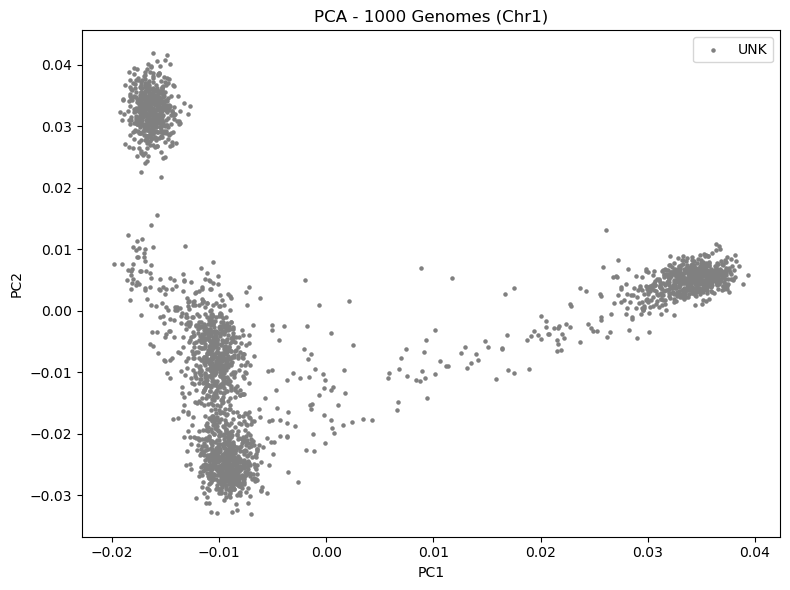

In [ ]:

# Load PCA
pca = pd.read_csv("chr22_pca.eigenvec", delim_whitespace=True, header=None)
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, 21)]

# --- Manual 1000 Genomes super population mapping ---
eur = ["CEU", "FIN", "GBR", "IBS", "TSI"]
afr = ["YRI", "LWK", "GWD", "MSL", "ESN", "ASW", "ACB"]
eas = ["CHB", "JPT", "CHS", "CDX", "KHV"]
amr = ["PEL", "MXL", "CLM", "PUR"]
sas = ["GIH", "PJL", "BEB", "STU"]

def assign_pop(x):
    if x in eur:
        return "EUR"
    elif x in afr:
        return "AFR"
    elif x in eas:
        return "EAS"
    elif x in amr:
        return "AMR"
    elif x in sas:
        return "SAS"
    else:
        return "UNK"

# Extract population code from IID
pca["pop"] = pca["IID"].str.split("_").str[0]
pca["super_pop"] = pca["pop"].apply(assign_pop)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

colors = {
    "AFR": "red",
    "AMR": "blue",
    "EAS": "green",
    "EUR": "orange",
    "SAS": "purple",
    "UNK": "grey"
}

for grp, df in pca.groupby("super_pop"):
    ax.scatter(df["PC1"], df["PC2"], s=5, color=colors.get(grp, "black"), label=grp)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - 1000 Genomes (Chr1)")
ax.legend()
plt.tight_layout()
plt.show()

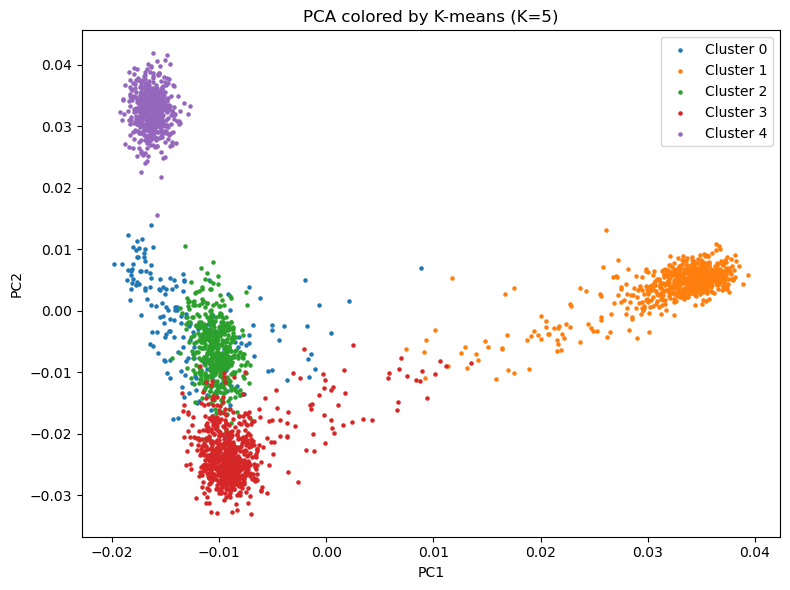

In [ ]:
X = pca[[f"PC{i}" for i in range(1, 11)]].values  # use PC1–PC10

k = 5  # choose your K
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
pca["cluster"] = kmeans.fit_predict(X)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(pca["cluster"].unique()):
    df = pca[pca["cluster"] == c]
    ax.scatter(df["PC1"], df["PC2"], s=5, label=f"Cluster {c}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA colored by K-means (K={k})")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
%%bash
admixture -j4 chr22_pruned.bed 3


****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 4 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x97735
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 23.484	Loglikelihood: -2.49312e+08	(delta): 1.51737e+08
2 (EM) 	Elapsed: 30.423	Loglikelihood:

In [ ]:
%%bash
admixture -j4 chr22_pruned.bed 5


****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 4 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x97735
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 32.309	Loglikelihood: -2.49596e+08	(delta): 1.29351e+08
2 (EM) 	Elapsed: 39.488	Loglikelihood:

In [ ]:
q <- read.table("chr1_pruned.3.Q")

barplot(t(as.matrix(q)),
        col=rainbow(3),
        xlab="Individuals",
        ylab="Ancestry proportion",
        border=NA)